Dataset shape: (1000, 9)
--- Model Performance Comparison ---
Decision Tree Accuracy: 85.50%
Random Forest Accuracy: 91.50%

Random Forest Detailed Report:
               precision    recall  f1-score   support

           0       0.95      0.88      0.91        99
           1       0.89      0.95      0.92       101

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.92      0.91       200



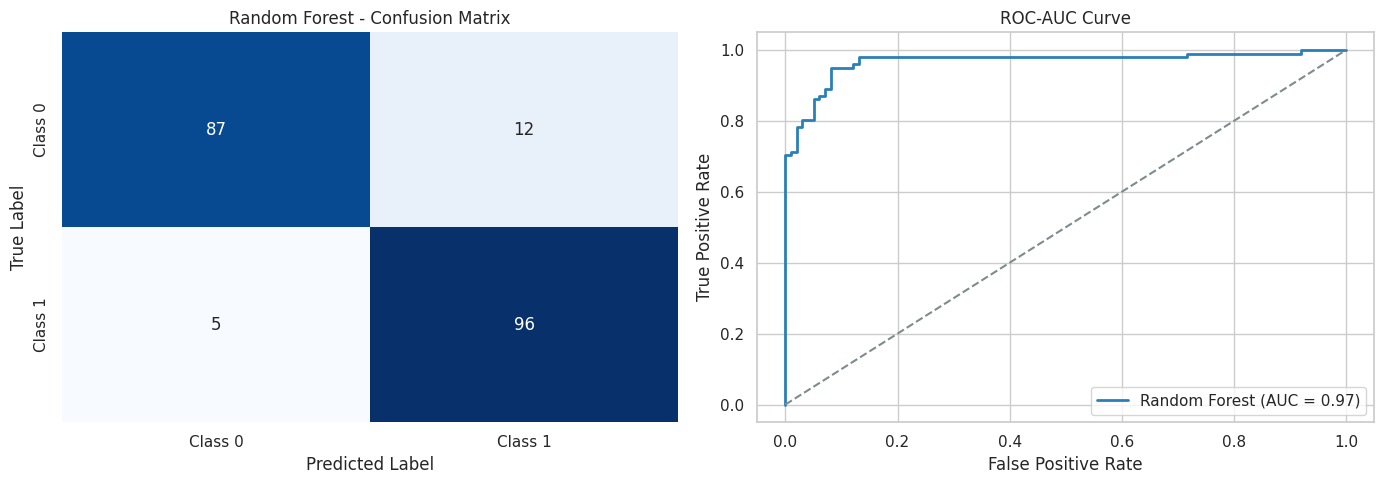

Model evaluation visual exported as model_performance.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# Set visual styling
sns.set_theme(style="whitegrid")

# 1. Generate a Synthetic Customer Churn Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=6,
    n_classes=2,
    random_state=42
)

feature_names = [f"Feature_{i+1}" for i in range(8)]
df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y

# Save raw dataset artifact
df.to_csv("dataset.csv", index=False)
print("Dataset shape:", df.shape)

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Model Training: Decision Tree vs Random Forest
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluation
print("--- Model Performance Comparison ---")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds) * 100:.2f}%")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print("\nRandom Forest Detailed Report:\n", classification_report(y_test, rf_preds))

# 5. Visualizations: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
axes[0].set_title("Random Forest - Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Plot B: ROC Curve for Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_probs)
auc_score = roc_auc_score(y_test, rf_probs)

axes[1].plot(fpr, tpr, color="#2980b9", lw=2, label=f"Random Forest (AUC = {auc_score:.2f})")
axes[1].plot([0, 1], [0, 1], color="#7f8c8d", linestyle="--")
axes[1].set_title("ROC-AUC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("model_performance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Model evaluation visual exported as model_performance.png")